#                                                             Assignment 1: End-to-End Machine Learning Project

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\rupab\OneDrive\Desktop\loan-default-prediction\DATASET\synthetic_dataset_10000x20.csv')
print("Shape:", df.shape)
df.head()

Shape: (10000, 21)


,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1


## STEP 1: EDA
1. Data types
2. Missing values
3. Unique values in categorical columns
4. Target class
5. Numeric distributions
6. Outlier detection
7. Categorical variable counts
8. Heatmap


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          10000 non-null  object 
 1   age                  10000 non-null  int64  
 2   income               9682 non-null   float64
 3   savings              9689 non-null   float64
 4   monthly_expenses     9675 non-null   float64
 5   num_dependents       10000 non-null  int64  
 6   credit_score         9674 non-null   float64
 7   loan_amount          10000 non-null  float64
 8   loan_term_months     10000 non-null  int64  
 9   employment_years     10000 non-null  float64
 10  home_ownership       10000 non-null  object 
 11  education            10000 non-null  object 
 12  marital_status       10000 non-null  object 
 13  region               10000 non-null  object 
 14  recent_default       10000 non-null  int64  
 15  has_credit_card      10000 non-null  

In [5]:
df.columns

Index(['customer_id', 'age', 'income', 'savings', 'monthly_expenses',
       'num_dependents', 'credit_score', 'loan_amount', 'loan_term_months',
       'employment_years', 'home_ownership', 'education', 'marital_status',
       'region', 'recent_default', 'has_credit_card', 'signup_date',
       'signup_dayofweek', 'debt_to_income', 'sin_age', 'target_default_risk'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          10000 non-null  object 
 1   age                  10000 non-null  int64  
 2   income               9682 non-null   float64
 3   savings              9689 non-null   float64
 4   monthly_expenses     9675 non-null   float64
 5   num_dependents       10000 non-null  int64  
 6   credit_score         9674 non-null   float64
 7   loan_amount          10000 non-null  float64
 8   loan_term_months     10000 non-null  int64  
 9   employment_years     10000 non-null  float64
 10  home_ownership       10000 non-null  object 
 11  education            10000 non-null  object 
 12  marital_status       10000 non-null  object 
 13  region               10000 non-null  object 
 14  recent_default       10000 non-null  int64  
 15  has_credit_card      10000 non-null  

In [7]:
df.columns

Index(['customer_id', 'age', 'income', 'savings', 'monthly_expenses',
       'num_dependents', 'credit_score', 'loan_amount', 'loan_term_months',
       'employment_years', 'home_ownership', 'education', 'marital_status',
       'region', 'recent_default', 'has_credit_card', 'signup_date',
       'signup_dayofweek', 'debt_to_income', 'sin_age', 'target_default_risk'],
      dtype='object')

In [8]:
df.isnull().sum()

customer_id              0
age                      0
income                 318
savings                311
monthly_expenses       325
num_dependents           0
credit_score           326
loan_amount              0
loan_term_months         0
employment_years         0
home_ownership           0
education                0
marital_status           0
region                   0
recent_default           0
has_credit_card          0
signup_date              0
signup_dayofweek         0
debt_to_income           0
sin_age                  0
target_default_risk      0
dtype: int64

In [9]:
# Unique values in categorical columns
for col in ['education', 'marital_status', 'region', 'home_ownership']:
    print(col, ":", df[col].unique())

education : ['HS' 'Bachelors' 'Masters' 'Other' 'PhD' 'Bachlors']
marital_status : ['Single' 'Married' 'Divorced' 'Widowed']
region : ['West' 'East' 'South' 'North']
home_ownership : ['RENT' 'OWN' 'MORTGAGE' 'OTHER']


target_default_risk
1    5132
0    4868
Name: count, dtype: int64


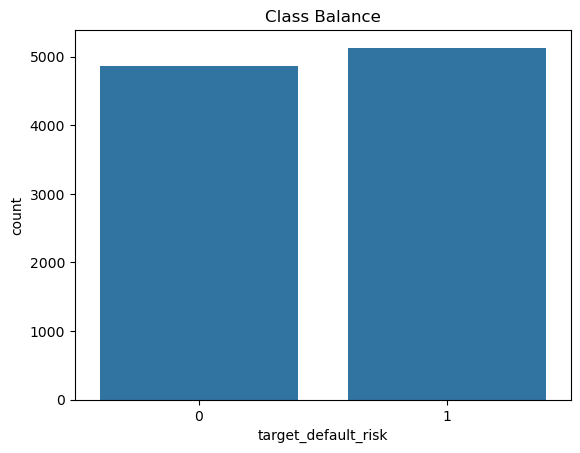

In [10]:
# Target class 
print(df['target_default_risk'].value_counts())
sns.countplot(x='target_default_risk', data=df)
plt.title("Class Balance")
plt.show()

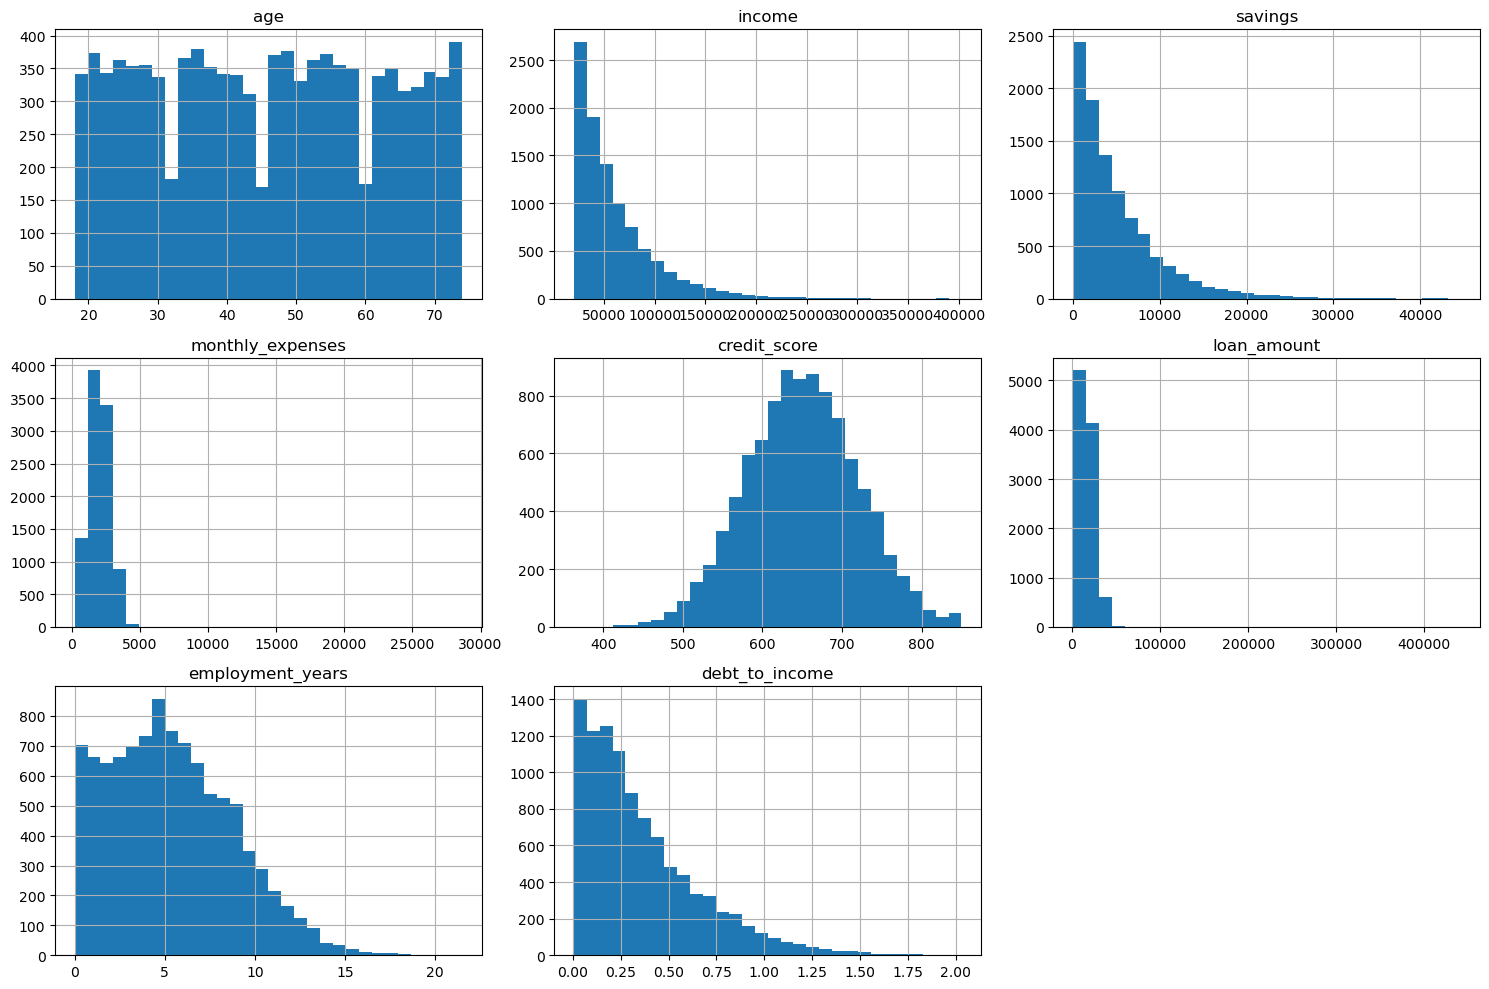

In [11]:
# Numeric distributions
numeric_cols = ['age', 'income', 'savings', 'monthly_expenses', 'credit_score',
                 'loan_amount', 'employment_years', 'debt_to_income']

df[numeric_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

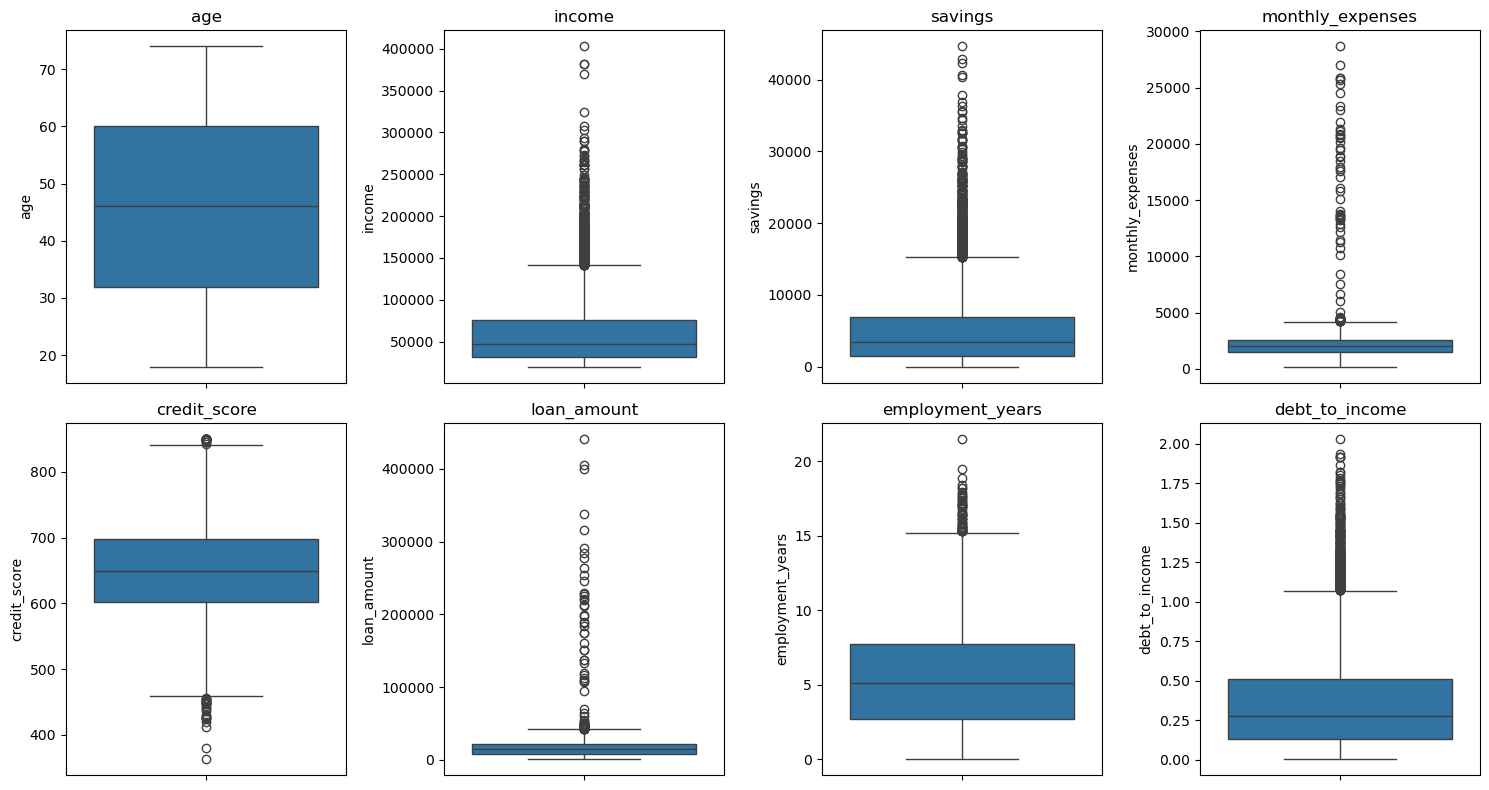

In [12]:
# Outlier detection (boxplots)
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

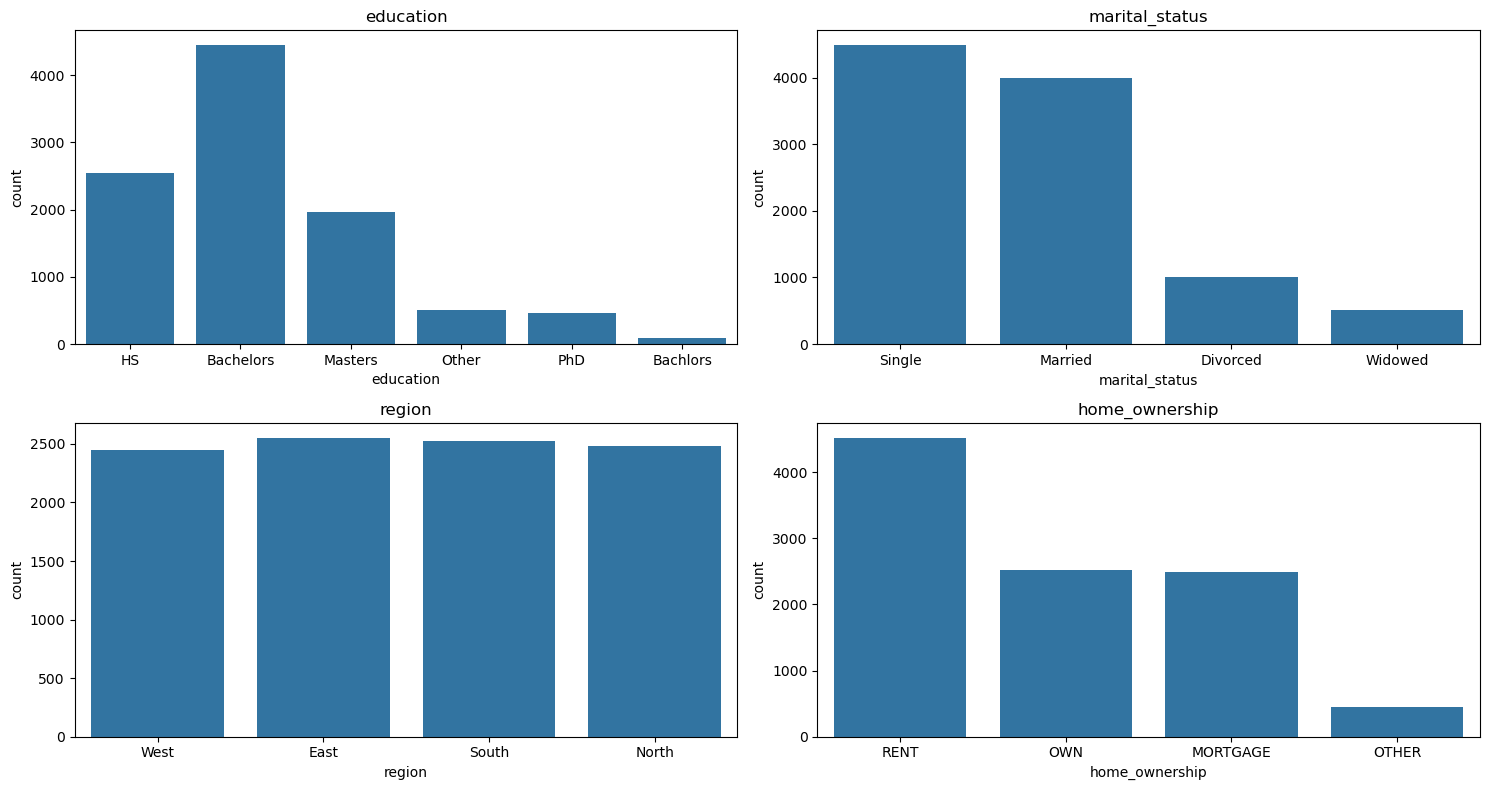

In [13]:
# Categorical variable counts
cat_cols = ['education', 'marital_status', 'region', 'home_ownership']
plt.figure(figsize=(15, 8))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=col, data=df)
    plt.title(col)
plt.tight_layout()
plt.show()

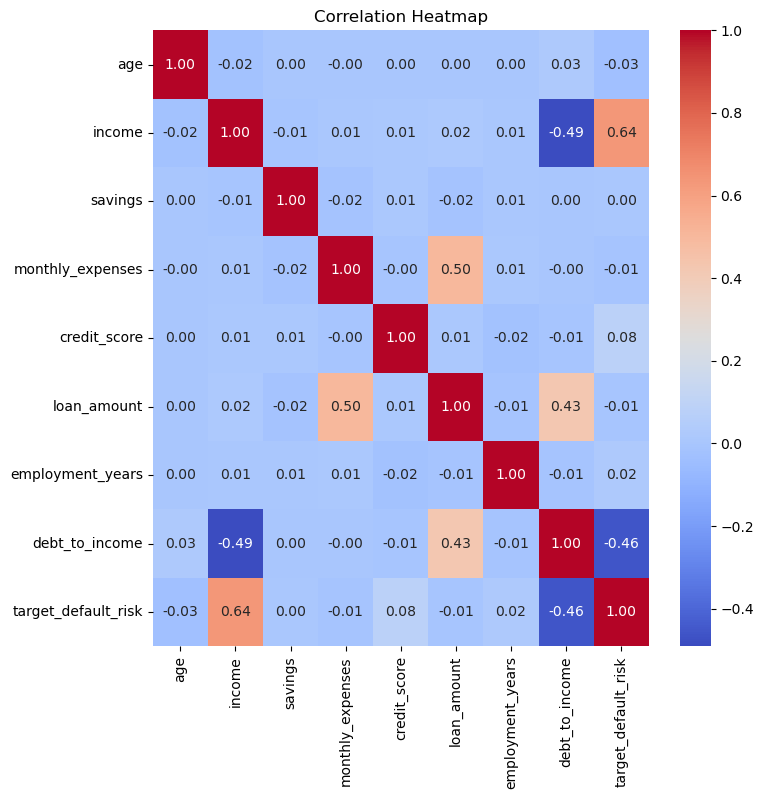

In [14]:
# heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(df[numeric_cols + ['target_default_risk']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# STEP 2 Feature Engineering
1.  Fix type in education
2.  Handle missing values
3.  New features
4.  Encode categorical variables

In [15]:
# Fix typo in education
df['education'] = df['education'].replace({'Bachlors': 'Bachelors'})
print(df['education'].unique())

['HS' 'Bachelors' 'Masters' 'Other' 'PhD']


In [16]:
# Handle missing values 
missing_cols = ['income', 'savings', 'monthly_expenses', 'credit_score']
for col in missing_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

customer_id            0
age                    0
income                 0
savings                0
monthly_expenses       0
num_dependents         0
credit_score           0
loan_amount            0
loan_term_months       0
employment_years       0
home_ownership         0
education              0
marital_status         0
region                 0
recent_default         0
has_credit_card        0
signup_date            0
signup_dayofweek       0
debt_to_income         0
sin_age                0
target_default_risk    0
dtype: int64


In [17]:
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in numeric_cols:
    df[col] = cap_outliers(df[col])

In [18]:
# New features
df['income_per_dependent'] = df['income'] / (df['num_dependents'] + 1)

df['signup_date'] = pd.to_datetime(df['signup_date'])
latest_date = df['signup_date'].max()
df['recency_days'] = (latest_date - df['signup_date']).dt.days

df.drop(columns=['signup_date', 'customer_id'], inplace=True)

In [19]:
# Encode categorical variables
df = pd.get_dummies(df, columns=['home_ownership', 'education', 'marital_status', 'region'], drop_first=True)
df.head()

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,recent_default,...,education_HS,education_Masters,education_Other,education_PhD,marital_status_Married,marital_status_Single,marital_status_Widowed,region_North,region_South,region_West
0,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,1,...,True,False,False,False,False,True,False,False,False,True
1,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,0,...,False,False,False,False,True,False,False,False,False,False
2,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,0,...,False,False,False,False,False,True,False,False,False,False
3,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,0,...,True,False,False,False,True,False,False,False,True,False
4,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,0,...,False,True,False,False,False,True,False,False,False,True


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target_default_risk'])
y = df['target_default_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## STEP 3: Model Evaluation

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [22]:
import sys
!{sys.executable} -m pip install xgboost

In [24]:
def evaluate_model(name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print()
    return acc, prec, rec, f1

metrics_dict = {}

In [25]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
metrics_dict["Logistic Regression"] = evaluate_model("Logistic Regression", y_test, y_pred_lr)

--- Logistic Regression ---
Accuracy : 0.9395
Precision: 0.9613
Recall   : 0.9191
F1 Score : 0.9397
Confusion Matrix:
 [[936  38]
 [ 83 943]]



In [26]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
metrics_dict["Decision Tree"] = evaluate_model("Decision Tree", y_test, y_pred_dt)


--- Decision Tree ---
Accuracy : 0.9280
Precision: 0.9315
Recall   : 0.9279
F1 Score : 0.9297
Confusion Matrix:
 [[904  70]
 [ 74 952]]



In [27]:
# SVM
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
metrics_dict["SVM"] = evaluate_model("SVM", y_test, y_pred_svm)

--- SVM ---
Accuracy : 0.9270
Precision: 0.9545
Recall   : 0.9006
F1 Score : 0.9268
Confusion Matrix:
 [[930  44]
 [102 924]]



In [28]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
metrics_dict["Random Forest"] = evaluate_model("Random Forest", y_test, y_pred_rf)


--- Random Forest ---
Accuracy : 0.9430
Precision: 0.9606
Recall   : 0.9269
F1 Score : 0.9435
Confusion Matrix:
 [[935  39]
 [ 75 951]]



In [29]:
# XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
metrics_dict["XGBoost"] = evaluate_model("XGBoost", y_test, y_pred_xgb)

--- XGBoost ---
Accuracy : 0.9560
Precision: 0.9644
Recall   : 0.9493
F1 Score : 0.9568
Confusion Matrix:
 [[938  36]
 [ 52 974]]



# STEP 4: Hyperparameter Tuning 



In [30]:
results_df = pd.DataFrame(metrics_dict, index=["Accuracy", "Precision", "Recall", "F1-Score"]).T
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print(results_df.round(4))

                     Accuracy  Precision  Recall  F1-Score
XGBoost                0.9560     0.9644  0.9493    0.9568
Random Forest          0.9430     0.9606  0.9269    0.9435
Logistic Regression    0.9395     0.9613  0.9191    0.9397
Decision Tree          0.9280     0.9315  0.9279    0.9297
SVM                    0.9270     0.9545  0.9006    0.9268


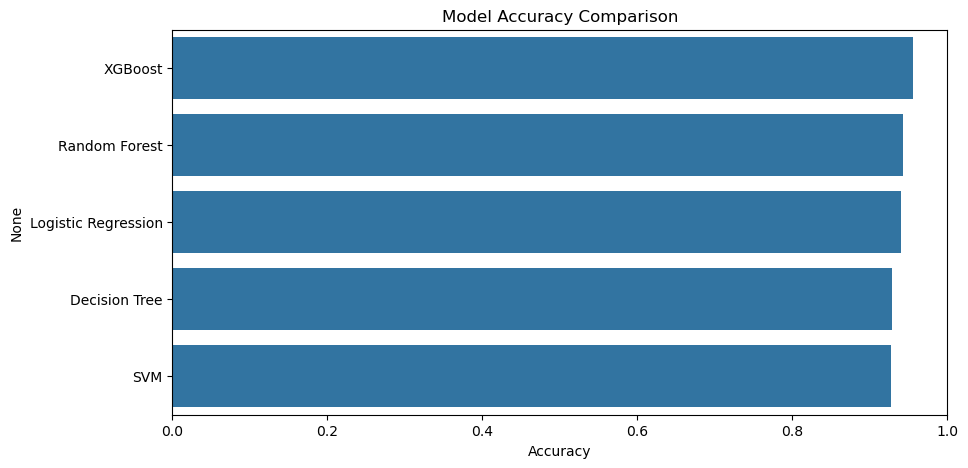

In [31]:
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df["Accuracy"], y=results_df.index)
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
plt.show()